In [1]:
import pickle
import numpy as np
import random

# Load RML2016 dataset
with open("RML2016.10a_dict.pkl", "rb") as f:
    data = pickle.load(f, encoding="latin1")

# Set target modulations and SNRs
target_modulations = ["GFSK", "BPSK", "QPSK", "8PSK", "QAM16", "QAM64"]
selected_snrs = [0, 4, 8, 12, 16]

# Containers
train_signals = []
train_labels = []
test_data_by_snr = {snr: {"signals": [], "labels": []} for snr in selected_snrs}

# Process and split data
for (mod, snr), signals in data.items():
    if mod in target_modulations and snr in selected_snrs:
        signals = np.array(signals)
        indices = list(range(len(signals)))
        random.shuffle(indices)

        # 800 for training, 200 for testing
        train_idx = indices[:800]
        test_idx = indices[800:]

        train_signals.append(signals[train_idx])
        train_labels.extend([mod] * len(train_idx))

        test_data_by_snr[snr]["signals"].append(signals[test_idx])
        test_data_by_snr[snr]["labels"].extend([mod] * len(test_idx))

# Combine and save training data
train_signals = np.concatenate(train_signals)
train_labels = np.array(train_labels)

with open("train_samples.pkl", "wb") as f:
    pickle.dump({"signals": train_signals, "labels": train_labels}, f)

# Save test data per SNR
for snr in selected_snrs:
    test_signals = np.concatenate(test_data_by_snr[snr]["signals"])
    test_labels = np.array(test_data_by_snr[snr]["labels"])
    with open(f"test_samples_snr{snr}.pkl", "wb") as f:
        pickle.dump({"signals": test_signals, "labels": test_labels}, f)

print("✅ All train and test files created with updated names.")


✅ All train and test files created with updated names.


In [2]:
import pickle
import numpy as np
import pandas as pd

def load_data(file_path):
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    return data["signals"], data["labels"]

# 🔍 Check training data
X_train, y_train = load_data("train_samples.pkl")
print("✅ Training data:")
print(f"Signals shape: {X_train.shape}")   # Expect (24000, 2, 128)
print(f"Labels count: {len(y_train)}")     # Expect 24000
print("Label distribution:")
print(pd.Series(y_train).value_counts())
print("\n")

# 🔍 Check test data for each SNR
for snr in [0, 4, 8, 12, 16]:
    file = f"test_samples_snr{snr}.pkl"
    X_test, y_test = load_data(file)
    print(f"✅ Test data for SNR {snr}:")
    print(f"Signals shape: {X_test.shape}")   # Expect (1200, 2, 128)
    print(f"Labels count: {len(y_test)}")     # Expect 1200
    print("Label distribution:")
    print(pd.Series(y_test).value_counts())
    print("\n")


✅ Training data:
Signals shape: (24000, 2, 128)
Labels count: 24000
Label distribution:
QAM64    4000
8PSK     4000
BPSK     4000
QAM16    4000
QPSK     4000
GFSK     4000
Name: count, dtype: int64


✅ Test data for SNR 0:
Signals shape: (1200, 2, 128)
Labels count: 1200
Label distribution:
BPSK     200
8PSK     200
GFSK     200
QAM16    200
QAM64    200
QPSK     200
Name: count, dtype: int64


✅ Test data for SNR 4:
Signals shape: (1200, 2, 128)
Labels count: 1200
Label distribution:
BPSK     200
QAM64    200
8PSK     200
GFSK     200
QAM16    200
QPSK     200
Name: count, dtype: int64


✅ Test data for SNR 8:
Signals shape: (1200, 2, 128)
Labels count: 1200
Label distribution:
QAM64    200
8PSK     200
QPSK     200
BPSK     200
QAM16    200
GFSK     200
Name: count, dtype: int64


✅ Test data for SNR 12:
Signals shape: (1200, 2, 128)
Labels count: 1200
Label distribution:
8PSK     200
QAM16    200
GFSK     200
QPSK     200
BPSK     200
QAM64    200
Name: count, dtype: int64


✅ Test 

In [1]:
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt
import joblib

# Load pre-saved training dataset
with open("train_samples.pkl", "rb") as f:
    train_data = pickle.load(f)

raw_signals = train_data["signals"]
labels = train_data["labels"]

# Your modulations and selected SNR (used only for model naming)
selected_snr = 10
target_modulations = ["GFSK", "BPSK", "QPSK", "8PSK", "QAM16", "QAM64"]

# ------------------- Feature Extraction (Same as yours) ------------------- #
def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.nan_to_num(np.abs(signal))
        signal_skew = skew(signal.flatten())
        signal_kurtosis = kurtosis(signal.flatten())
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal.flatten())) != 0) / len(signal.flatten())
        mean_absolute_deviation = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        hjorth_activity = np.var(signal)
        hjorth_mobility = np.sqrt(np.var(np.diff(signal)) / hjorth_activity) if hjorth_activity != 0 else 0
        hjorth_complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / hjorth_mobility) if hjorth_mobility != 0 else 0
        fft_signal = np.abs(fft(signal.flatten()))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid) ** 2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2) if np.mean(fft_signal) != 0 else 0
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])
        coeffs = pywt.wavedec(signal.flatten(), 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conjugate(signal))
        M22 = np.mean(np.conjugate(signal) ** 2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conjugate(signal))
        M42 = np.mean(signal**2 * np.conjugate(signal) ** 2)
        M43 = np.mean(signal * np.conjugate(signal) ** 3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)
        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21) ** 2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * (M20**2) - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20
        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
                         mean_absolute_deviation, shannon_entropy, hjorth_activity, hjorth_mobility, hjorth_complexity,
                         fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
                         fft_low, fft_mid, fft_high, wavelet_energy, wavelet_entropy, wavelet_detail_energy,
                         M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120, C20, C40, C41, C42, C60, C80, C100,
                         r1, r2, r16, r17, r18, r19, r20, papr, crest_factor])
    return np.array(features)

# ------------------- Feature Processing Pipeline ------------------- #

# Extract features
X = extract_features(raw_signals)

# Encode modulation labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca_components = 25 if selected_snr <= 8 else 25
pca = PCA(n_components=pca_components)
X_pca = pca.fit_transform(X_scaled)

# Polynomial expansion
poly = PolynomialFeatures(degree=2, interaction_only=True)
X_poly = poly.fit_transform(X_pca)

# Train SVM on full dataset
param_grid = {"C": [0.001, 0.01, 0.1, 10, 100]}
svm_grid = GridSearchCV(SVC(kernel="linear", class_weight="balanced"), param_grid, cv=5, n_jobs=-1, verbose=1)
svm_grid.fit(X_poly, y)

# Save trained model
joblib.dump(svm_grid.best_estimator_, f"final_best_linear_svm_snr{selected_snr}_trained.pkl")
print("✅ Model trained and saved.")


Fitting 5 folds for each of 5 candidates, totalling 25 fits


KeyboardInterrupt: 

In [3]:
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt
import joblib

# Load training data
with open("train_samples.pkl", "rb") as f:
    data = pickle.load(f)

signals = data["signals"]
labels = data["labels"]

# Set the SNR value (for naming only)
selected_snr = 15  # Just for output file naming

# Feature extraction (same as your full pipeline)
def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.nan_to_num(np.abs(signal))
        signal_skew = skew(signal.flatten())
        signal_kurtosis = kurtosis(signal.flatten())
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal.flatten())) != 0) / len(signal.flatten())  
        mean_absolute_deviation = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        hjorth_activity = np.var(signal)
        hjorth_mobility = np.sqrt(np.var(np.diff(signal)) / hjorth_activity) if hjorth_activity != 0 else 0
        hjorth_complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / hjorth_mobility) if hjorth_mobility != 0 else 0
        fft_signal = np.abs(fft(signal.flatten()))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid) ** 2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2) if np.mean(fft_signal) != 0 else 0
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])
        coeffs = pywt.wavedec(signal.flatten(), 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))  
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conjugate(signal))
        M22 = np.mean(np.conjugate(signal) ** 2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conjugate(signal))
        M42 = np.mean(signal**2 * np.conjugate(signal) ** 2)
        M43 = np.mean(signal * np.conjugate(signal) ** 3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)
        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21) ** 2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * (M20**2) - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20
        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
                         mean_absolute_deviation, shannon_entropy, hjorth_activity, hjorth_mobility, hjorth_complexity,
                         fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
                         fft_low, fft_mid, fft_high, wavelet_energy, wavelet_entropy, wavelet_detail_energy,
                         M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120, C20, C40, C41, C42, C60, C80, C100,
                         r1, r2, r16, r17, r18, r19, r20, papr, crest_factor])
    return np.array(features)

# Apply feature extraction
X = extract_features(signals)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca_components = 25 if selected_snr <= 8 else 25
pca = PCA(n_components=pca_components)
X_pca = pca.fit_transform(X_scaled)

# Apply polynomial expansion
poly = PolynomialFeatures(degree=2, interaction_only=True)
X_poly = poly.fit_transform(X_pca)

# Train SVM on the full dataset
param_grid = {"C": [0.001, 0.01, 0.1, 10, 100]}
svm_grid = GridSearchCV(SVC(kernel="linear", class_weight="balanced"), param_grid, cv=5, n_jobs=-1, verbose=1)
svm_grid.fit(X_poly, y)

# Save the trained model
joblib.dump(svm_grid.best_estimator_, f"final_best_linear_svm_snr{selected_snr}_trained.pkl")
print("✅ Model trained and saved as final_best_linear_svm_snr{selected_snr}_trained.pkl")


Fitting 5 folds for each of 5 candidates, totalling 25 fits
✅ Model trained and saved as final_best_linear_svm_snr{selected_snr}_trained.pkl


🎯 Accuracy on SNR 4 test set: 0.28

Classification Report:
              precision    recall  f1-score   support

        8PSK       0.20      0.27      0.23       200
        BPSK       0.19      0.33      0.24       200
        GFSK       0.93      0.35      0.51       200
       QAM16       0.16      0.17      0.17       200
       QAM64       0.43      0.47      0.45       200
        QPSK       0.29      0.12      0.17       200

    accuracy                           0.28      1200
   macro avg       0.37      0.28      0.29      1200
weighted avg       0.37      0.28      0.29      1200



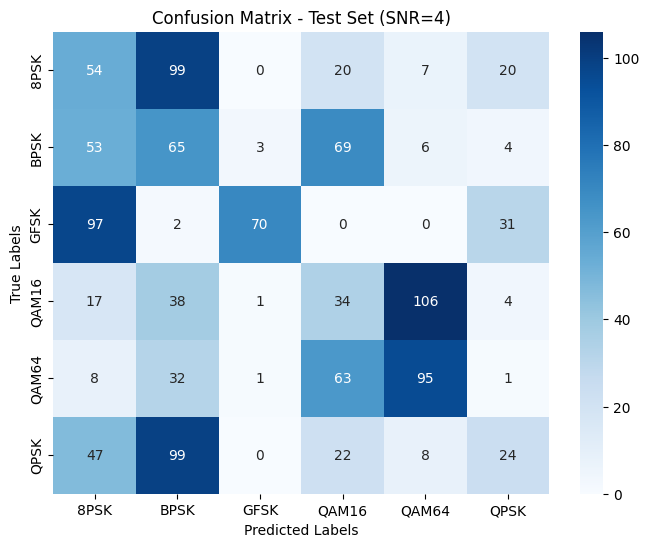

In [6]:
import pickle
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load test dataset (change SNR here)
snr = 4
with open(f"test_samples_snr{snr}.pkl", "rb") as f:
    test_data = pickle.load(f)

X_test_raw = test_data["signals"]
y_test_labels = test_data["labels"]

# Feature extraction (same as training)
def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.nan_to_num(np.abs(signal))
        signal_skew = skew(signal.flatten())
        signal_kurtosis = kurtosis(signal.flatten())
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal.flatten())) != 0) / len(signal.flatten())  
        mean_absolute_deviation = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        hjorth_activity = np.var(signal)
        hjorth_mobility = np.sqrt(np.var(np.diff(signal)) / hjorth_activity) if hjorth_activity != 0 else 0
        hjorth_complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / hjorth_mobility) if hjorth_mobility != 0 else 0
        fft_signal = np.abs(fft(signal.flatten()))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid) ** 2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2) if np.mean(fft_signal) != 0 else 0
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])
        coeffs = pywt.wavedec(signal.flatten(), 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))  
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conjugate(signal))
        M22 = np.mean(np.conjugate(signal) ** 2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conjugate(signal))
        M42 = np.mean(signal**2 * np.conjugate(signal) ** 2)
        M43 = np.mean(signal * np.conjugate(signal) ** 3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)
        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21) ** 2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * (M20**2) - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20
        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
                         mean_absolute_deviation, shannon_entropy, hjorth_activity, hjorth_mobility, hjorth_complexity,
                         fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
                         fft_low, fft_mid, fft_high, wavelet_energy, wavelet_entropy, wavelet_detail_energy,
                         M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120, C20, C40, C41, C42, C60, C80, C100,
                         r1, r2, r16, r17, r18, r19, r20, papr, crest_factor])
    return np.array(features)

# Apply feature extraction
X_test = extract_features(X_test_raw)

# Encode labels using the same order as training
label_encoder = LabelEncoder()
label_encoder.fit(["GFSK", "BPSK", "QPSK", "8PSK", "QAM16", "QAM64"])
y_test = label_encoder.transform(y_test_labels)

# Preprocessing pipeline (same as training)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)  # Should ideally use the same scaler from training

pca = PCA(n_components=25)  # Match with training config
X_test_pca = pca.fit_transform(X_test_scaled)

poly = PolynomialFeatures(degree=2, interaction_only=True)
X_test_poly = poly.fit_transform(X_test_pca)

# Load trained model
model = joblib.load("final_best_linear_svm_snr15_trained.pkl")

# Predict and evaluate
y_pred = model.predict(X_test_poly)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Accuracy on SNR {snr} test set: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title(f"Confusion Matrix - Test Set (SNR={snr})")
plt.show()


In [8]:
# train_rml_pipeline.py

import pickle
import numpy as np
import os
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# Load training data
with open("train_samples.pkl", "rb") as f:
    train_data = pickle.load(f)

signals = train_data["signals"]
labels = train_data["labels"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)

# Feature extraction (same as before)
def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.abs(signal)
        signal_skew = skew(signal.flatten())
        signal_kurtosis = kurtosis(signal.flatten())
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal.flatten())) != 0) / len(signal.flatten())
        mad = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        activity = np.var(signal)
        mobility = np.sqrt(np.var(np.diff(signal)) / activity) if activity != 0 else 0
        complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / mobility) if mobility != 0 else 0
        fft_signal = np.abs(fft(signal.flatten()))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid)**2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2 + 1e-10)
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])
        coeffs = pywt.wavedec(signal.flatten(), 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conj(signal))
        M22 = np.mean(np.conj(signal)**2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conj(signal))
        M42 = np.mean(signal**2 * np.conj(signal)**2)
        M43 = np.mean(signal * np.conj(signal)**3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)
        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21)**2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * M20**2 - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20
        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([
            signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
            mad, shannon_entropy, activity, mobility, complexity,
            fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
            fft_low, fft_mid, fft_high,
            wavelet_energy, wavelet_entropy, wavelet_detail_energy,
            M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120,
            C20, C40, C41, C42, C60, C80, C100,
            r1, r2, r16, r17, r18, r19, r20, papr, crest_factor
        ])
    return np.array(features)

# Feature extraction
X = extract_features(signals)

# Build full pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20)),
    ('poly', PolynomialFeatures(degree=2, interaction_only=True)),
    ('svm', SVC(kernel="linear", class_weight="balanced"))
])

# Grid search
param_grid = {"svm__C": [0.01, 0.1, 1, 10]}
svm_grid = GridSearchCV(pipeline, param_grid, cv=4, n_jobs=-1, verbose=1)
svm_grid.fit(X, y_encoded)

# Save
os.makedirs("models_rml", exist_ok=True)
joblib.dump(svm_grid.best_estimator_, "models_rml/full_pipeline_rml.pkl")
joblib.dump(label_encoder, "models_rml/rml_label_encoder.pkl")

print("✅ Trained model and encoder saved to 'models_rml/'")


Fitting 4 folds for each of 4 candidates, totalling 16 fits
✅ Trained model and encoder saved to 'models_rml/'


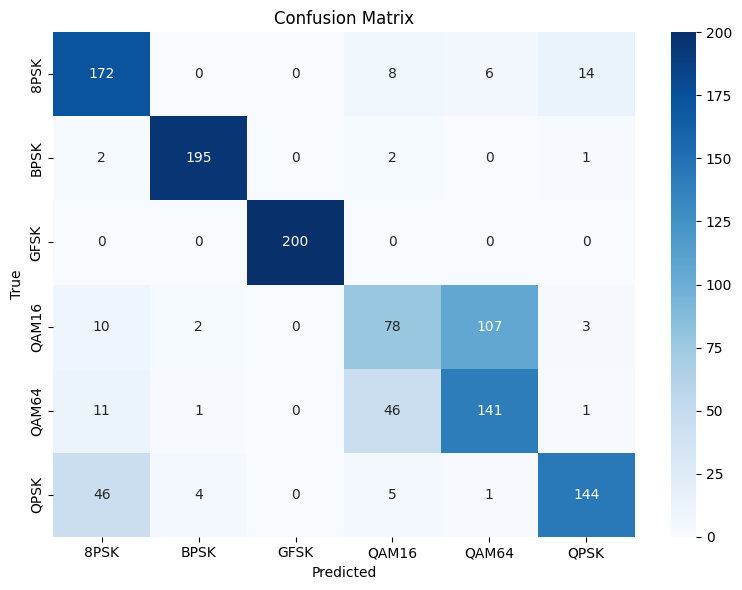


Classification Report:
              precision    recall  f1-score   support

        8PSK       0.71      0.86      0.78       200
        BPSK       0.97      0.97      0.97       200
        GFSK       1.00      1.00      1.00       200
       QAM16       0.56      0.39      0.46       200
       QAM64       0.55      0.70      0.62       200
        QPSK       0.88      0.72      0.79       200

    accuracy                           0.78      1200
   macro avg       0.78      0.78      0.77      1200
weighted avg       0.78      0.78      0.77      1200



In [3]:
import numpy as np
import pickle
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from scipy.fft import fft
from scipy.stats import skew, kurtosis, entropy
import pywt

# -------------------------------
# Load Test File (change SNR here)
# -------------------------------
snr = 12  # change to 4, 8, 12, etc.
with open(f"test_samples_snr{snr}.pkl", "rb") as f:
    test_data = pickle.load(f)

signals = test_data["signals"]
labels = test_data["labels"]

# -------------------------------
# Load Trained Model and Label Encoder
# -------------------------------
pipeline = joblib.load("models_rml/full_pipeline_rml.pkl")
label_encoder = joblib.load("models_rml/rml_label_encoder.pkl")

# -------------------------------
# Feature Extraction (same as training)
# -------------------------------
def extract_features(signals):
    features = []
    for signal in signals:
        signal = np.array(signal)
        magnitude = np.abs(signal)
        signal_skew = skew(signal.flatten())
        signal_kurtosis = kurtosis(signal.flatten())
        signal_energy = np.sum(np.abs(signal)**2)
        signal_variance = np.var(signal)
        signal_zcr = np.sum(np.diff(np.sign(signal.flatten())) != 0) / len(signal.flatten())
        mad = np.mean(np.abs(signal - np.mean(signal)))
        shannon_entropy = -np.sum(signal * np.log2(np.abs(signal) + 1e-10))
        activity = np.var(signal)
        mobility = np.sqrt(np.var(np.diff(signal)) / activity) if activity != 0 else 0
        complexity = np.sqrt(np.var(np.diff(np.diff(signal))) / mobility) if mobility != 0 else 0
        fft_signal = np.abs(fft(signal.flatten()))
        fft_mean = np.mean(fft_signal)
        fft_max = np.max(fft_signal)
        fft_entropy = entropy(fft_signal)
        spectral_centroid = np.sum(np.arange(len(fft_signal)) * fft_signal) / np.sum(fft_signal)
        spectral_spread = np.sqrt(np.sum(((np.arange(len(fft_signal)) - spectral_centroid)**2) * fft_signal) / np.sum(fft_signal))
        spectral_flatness = np.var(fft_signal) / (np.mean(fft_signal)**2 + 1e-10)
        fft_low = np.sum(fft_signal[:len(fft_signal)//3])
        fft_mid = np.sum(fft_signal[len(fft_signal)//3:2*len(fft_signal)//3])
        fft_high = np.sum(fft_signal[2*len(fft_signal)//3:])
        coeffs = pywt.wavedec(signal.flatten(), 'db1', level=3)
        wavelet_energy = sum(np.linalg.norm(c) for c in coeffs)
        wavelet_entropy = entropy(np.abs(coeffs[-1]))
        wavelet_detail_energy = np.sum(np.square(coeffs[-1]))
        M20 = np.mean(signal**2)
        M21 = np.mean(signal * np.conj(signal))
        M22 = np.mean(np.conj(signal)**2)
        M40 = np.mean(signal**4)
        M41 = np.mean(signal**3 * np.conj(signal))
        M42 = np.mean(signal**2 * np.conj(signal)**2)
        M43 = np.mean(signal * np.conj(signal)**3)
        M60 = np.mean(signal**6)
        M80 = np.mean(signal**8)
        M100 = np.mean(signal**10)
        M120 = np.mean(signal**12)
        C20 = M20
        C40 = M40 - 3 * (M20**2)
        C41 = M41 - 3 * M20 * M21
        C42 = M42 - 2 * M21 - np.abs(M21)**2
        C60 = M60 - 15 * C40 * M20 + 30 * (M20**3)
        C80 = M80 - 630 * M20**4 + 420 * C40 * M20**2 - 28 * C60 * M20 - 35 * (C40**2)
        C100 = M100 - 9 * C80 * C20
        r1 = np.abs(C40) / np.abs(C42) if np.abs(C42) != 0 else 0
        r2 = np.abs(C41) / np.abs(C42) if np.abs(C42) != 0 else 0
        r16 = np.abs(C80) / np.abs(C20) if np.abs(C20) != 0 else 0
        r17 = np.abs(C100) / np.abs(C40) if np.abs(C40) != 0 else 0
        r18 = np.abs(C100) / np.abs(C60) if np.abs(C60) != 0 else 0
        r19 = np.abs(C80) / np.abs(C60) if np.abs(C60) != 0 else 0
        r20 = np.abs(C100) / np.abs(C20) if np.abs(C20) != 0 else 0
        papr = (np.max(magnitude) ** 2) / (np.mean(magnitude ** 2) + 1e-10)
        crest_factor = np.max(magnitude) / (np.sqrt(np.mean(magnitude ** 2)) + 1e-10)

        features.append([
            signal_skew, signal_kurtosis, signal_energy, signal_variance, signal_zcr,
            mad, shannon_entropy, activity, mobility, complexity,
            fft_mean, fft_max, fft_entropy, spectral_centroid, spectral_spread, spectral_flatness,
            fft_low, fft_mid, fft_high,
            wavelet_energy, wavelet_entropy, wavelet_detail_energy,
            M20, M21, M22, M40, M41, M42, M43, M60, M80, M100, M120,
            C20, C40, C41, C42, C60, C80, C100,
            r1, r2, r16, r17, r18, r19, r20, papr, crest_factor
        ])
    return np.array(features)

# -------------------------------
# Predict and Evaluate
# -------------------------------
X = extract_features(signals)
y_true = label_encoder.transform(labels)
y_pred = pipeline.predict(X)

#print("\nClassification Report:")
#print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))
